<a href="https://colab.research.google.com/github/indhujaya2014-web/Aerial_Object-Classification_and_Detection/blob/main/Project_5_Aerial_Object_Classification_and_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import libraries

In [16]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0, MobileNet
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Upload Dataset

In [19]:
# Verify folder
!ls

classification_dataset.zip  object_detection_Dataset.zip  sample_data


In [20]:
# unzip dataset
!unzip classification_dataset.zip

Archive:  classification_dataset.zip
  inflating: classification_dataset/test/bird/0085fed0b90de5ba_jpg.rf.ace2ac82f6145bc68aef8c8a9cdd74bb.jpg  
  inflating: classification_dataset/test/bird/06b3bc9d00e0bd0c_jpg.rf.db81bbe2cdd9edb36e3405001602520c.jpg  
  inflating: classification_dataset/test/bird/1635c925ad4d0ef0_jpg.rf.51670241c892392b554d9144e4b76054.jpg  
  inflating: classification_dataset/test/bird/006ce62a72df4dd4_jpg.rf.8f8e7b6e9a26a01be91ea1b7dc4011d2.jpg  
  inflating: classification_dataset/test/bird/0028adf0e92c3da2_jpg.rf.48c97d30547a46e83abcbd1bf801c72f.jpg  
  inflating: classification_dataset/test/bird/00ddd713b6f26a17_jpg.rf.0756de13413d353595f8a65e9300b032.jpg  
  inflating: classification_dataset/test/bird/0df304b575cc0852_jpg.rf.60869438d34e69a930ef9cf937fa1d49.jpg  
  inflating: classification_dataset/test/bird/10b85be90200a58a_jpg.rf.32f900cada4505148337c33c5a449bb4.jpg  
  inflating: classification_dataset/test/bird/1cdea8304a2d2c55_jpg.rf.06c38fb0a95cc9565d402

In [21]:
# Verify folder structure
!ls

classification_dataset	    object_detection_Dataset.zip
classification_dataset.zip  sample_data


In [22]:
!ls classification_dataset

test  train  valid


In [23]:
!ls classification_dataset/train

bird  drone


# Data Loading and Preprocessing

In [24]:
# parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [25]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.2,
    brightness_range=[0.8,1.2]
)

val_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    "classification_dataset/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

val_data = val_gen.flow_from_directory(
    "classification_dataset/valid",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

test_data = test_gen.flow_from_directory(
    "classification_dataset/test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 2662 images belonging to 2 classes.
Found 442 images belonging to 2 classes.
Found 215 images belonging to 2 classes.


# Custom CNN Model

In [26]:
from tensorflow.keras import layers, models

def build_custom_cnn():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(64, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(128, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
    )
    return model

custom_model = build_custom_cnn()
custom_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,473 (42.61 MB)

 Trainable params: 11,169,281 (42.61 MB)

 Non-trainable params: 192 (768.00 B)

# Transfer Learning (MobileNet/EfficientNetB0 Example)



In [27]:
def build_transfer_model():
    # base_model = EfficientNetB0
    base_model = MobileNet(
        weights='imagenet',
        include_top=False,
        input_shape=(224,224,3)
    )

    base_model.trainable = False

    model = tf.keras.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy',
                 tf.keras.metrics.Precision(),
                 tf.keras.metrics.Recall()]
    )

    return model

# Model Training

In [28]:
import time
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ModelCheckpoint("models/best_model.h5", save_best_only=True)
]

# ---- Custom CNN ----
custom_model = build_custom_cnn()

start_time = time.time()
history_custom = custom_model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=callbacks
)
custom_time = time.time() - start_time

# ---- Transfer Learning ----
transfer_model = build_transfer_model()

start_time = time.time()
history_transfer = transfer_model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=callbacks
)
transfer_time = time.time() - start_time

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 497ms/step - accuracy: 0.5564 - loss: 10.5330 - precision_1: 0.5462 - recall_1: 0.5120

84/84 ━━━━━━━━━━━━━━━━━━━━ 56s 551ms/step - accuracy: 0.5568 - loss: 10.4506 - precision_1: 0.5468 - recall_1: 0.5108 - val_accuracy: 0.6810 - val_loss: 0.6316 - val_precision_1: 0.9118 - val_recall_1: 0.4133
Epoch 2/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 68s 466ms/step - accuracy: 0.6036 - loss: 0.6393 - precision_1: 0.7736 - recall_1: 0.1798 - val_accuracy: 0.4910 - val_loss: 0.6702 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00
Epoch 3/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 40s 471ms/step - accuracy: 0.6207 - loss: 0.6154 - precision_1: 0.6542 - recall_1: 0.5061 - val_accuracy: 0.6810 - val_loss: 0.6618 - val_precision_1: 0.8621 - val_recall_1: 0.4444
Epoch 4/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 39s 469ms/step - accuracy: 0.6397 - loss: 0.5758 - precision_1: 0.5914 - recall_1: 0.7906 - val_accuracy: 0.6991 - val_loss: 0.6413 - val_precision_1: 0.8108 - val_recall_1: 0.5333
Epoch 5/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 459ms/step - accuracy: 0.6434 - loss: 0.5754 - precision_1: 0.6540 - recall_1: 0.5655

84/84 ━━━━━━━━━━━━━━━━━━━━ 40s 476ms/step - accuracy: 0.6435 - loss: 0.5755 - precision_1: 0.6549 - recall_1: 0.5636 - val_accuracy: 0.6810 - val_loss: 0.5868 - val_precision_1: 0.9286 - val_recall_1: 0.4044
Epoch 6/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 39s 462ms/step - accuracy: 0.6164 - loss: 0.5965 - precision_1: 0.8044 - recall_1: 0.2801 - val_accuracy: 0.7059 - val_loss: 0.6206 - val_precision_1: 0.8740 - val_recall_1: 0.4933
Epoch 7/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 39s 462ms/step - accuracy: 0.6189 - loss: 0.6300 - precision_1: 0.5687 - recall_1: 0.8780 - val_accuracy: 0.7670 - val_loss: 0.6072 - val_precision_1: 0.7460 - val_recall_1: 0.8222
Epoch 8/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 39s 463ms/step - accuracy: 0.6428 - loss: 0.6215 - precision_1: 0.5770 - recall_1: 0.9024 - val_accuracy: 0.7376 - val_loss: 0.5931 - val_precision_1: 0.7057 - val_recall_1: 0.8311
Epoch 9/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step - accuracy: 0.7059 - loss: 0.5849 - precision_1: 0.6451 - recall_1: 0.8445

84/84 ━━━━━━━━━━━━━━━━━━━━ 39s 467ms/step - accuracy: 0.7057 - loss: 0.5848 - precision_1: 0.6448 - recall_1: 0.8444 - val_accuracy: 0.7919 - val_loss: 0.4954 - val_precision_1: 0.7568 - val_recall_1: 0.8711
Epoch 10/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 39s 466ms/step - accuracy: 0.6942 - loss: 0.5632 - precision_1: 0.6239 - recall_1: 0.8304 - val_accuracy: 0.7602 - val_loss: 0.5501 - val_precision_1: 0.8400 - val_recall_1: 0.6533
Epoch 11/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 39s 466ms/step - accuracy: 0.6945 - loss: 0.5391 - precision_1: 0.6209 - recall_1: 0.8778 - val_accuracy: 0.7014 - val_loss: 2.1402 - val_precision_1: 0.6405 - val_recall_1: 0.9422
Epoch 12/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step - accuracy: 0.6960 - loss: 0.5555 - precision_1: 0.6312 - recall_1: 0.8507

...

84/84 ━━━━━━━━━━━━━━━━━━━━ 39s 465ms/step - accuracy: 0.9702 - loss: 0.0790 - precision_2: 0.9682 - recall_2: 0.9665 - val_accuracy: 0.9683 - val_loss: 0.0714 - val_precision_2: 0.9648 - val_recall_2: 0.9733
Epoch 8/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 38s 447ms/step - accuracy: 0.9723 - loss: 0.0758 - precision_2: 0.9663 - recall_2: 0.9749 - val_accuracy: 0.9615 - val_loss: 0.0786 - val_precision_2: 0.9815 - val_recall_2: 0.9422
Epoch 9/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 38s 453ms/step - accuracy: 0.9659 - loss: 0.0793 - precision_2: 0.9757 - recall_2: 0.9514 - val_accuracy: 0.9661 - val_loss: 0.0735 - val_precision_2: 0.9817 - val_recall_2: 0.9511
Epoch 10/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.9730 - loss: 0.0668 - precision_2: 0.9710 - recall_2: 0.9722

84/84 ━━━━━━━━━━━━━━━━━━━━ 39s 460ms/step - accuracy: 0.9730 - loss: 0.0668 - precision_2: 0.9710 - recall_2: 0.9722 - val_accuracy: 0.9729 - val_loss: 0.0696 - val_precision_2: 0.9776 - val_recall_2: 0.9689
Epoch 11/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - accuracy: 0.9740 - loss: 0.0720 - precision_2: 0.9729 - recall_2: 0.9702

84/84 ━━━━━━━━━━━━━━━━━━━━ 39s 462ms/step - accuracy: 0.9740 - loss: 0.0720 - precision_2: 0.9729 - recall_2: 0.9703 - val_accuracy: 0.9729 - val_loss: 0.0694 - val_precision_2: 0.9776 - val_recall_2: 0.9689
Epoch 12/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step - accuracy: 0.9743 - loss: 0.0663 - precision_2: 0.9805 - recall_2: 0.9641

84/84 ━━━━━━━━━━━━━━━━━━━━ 39s 466ms/step - accuracy: 0.9743 - loss: 0.0663 - precision_2: 0.9804 - recall_2: 0.9641 - val_accuracy: 0.9774 - val_loss: 0.0691 - val_precision_2: 0.9778 - val_recall_2: 0.9778
Epoch 13/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step - accuracy: 0.9806 - loss: 0.0558 - precision_2: 0.9812 - recall_2: 0.9779

84/84 ━━━━━━━━━━━━━━━━━━━━ 39s 464ms/step - accuracy: 0.9806 - loss: 0.0559 - precision_2: 0.9811 - recall_2: 0.9779 - val_accuracy: 0.9796 - val_loss: 0.0671 - val_precision_2: 0.9779 - val_recall_2: 0.9822
Epoch 14/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 38s 456ms/step - accuracy: 0.9781 - loss: 0.0589 - precision_2: 0.9784 - recall_2: 0.9747 - val_accuracy: 0.9706 - val_loss: 0.0706 - val_precision_2: 0.9775 - val_recall_2: 0.9644
Epoch 15/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 39s 460ms/step - accuracy: 0.9820 - loss: 0.0541 - precision_2: 0.9818 - recall_2: 0.9793 - val_accuracy: 0.9796 - val_loss: 0.0684 - val_precision_2: 0.9779 - val_recall_2: 0.9822
Epoch 16/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 38s 457ms/step - accuracy: 0.9792 - loss: 0.0624 - precision_2: 0.9755 - recall_2: 0.9806 - val_accuracy: 0.9706 - val_loss: 0.0739 - val_precision_2: 0.9818 - val_recall_2: 0.9600
Epoch 17/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 38s 454ms/step - accuracy: 0.9814 - loss: 0.0583 - precision_2: 0.9839 - recall_2: 0.9771 - v

# Model Evaluation

In [29]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns

def evaluate_model(model, name):
    print(f"\n🔍 Evaluating {name}")

    # prediction
    y_pred = (model.predict(test_data) > 0.5).astype("int32")
    y_true = test_data.classes

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    test_loss, test_acc, test_prec, test_rec = model.evaluate(test_data)

    return test_acc

# Evaluate Both Models


🔍 Evaluating Custom CNN
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 308ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.87      0.87       121
           1       0.83      0.83      0.83        94

    accuracy                           0.85       215
   macro avg       0.85      0.85      0.85       215
weighted avg       0.85      0.85      0.85       215



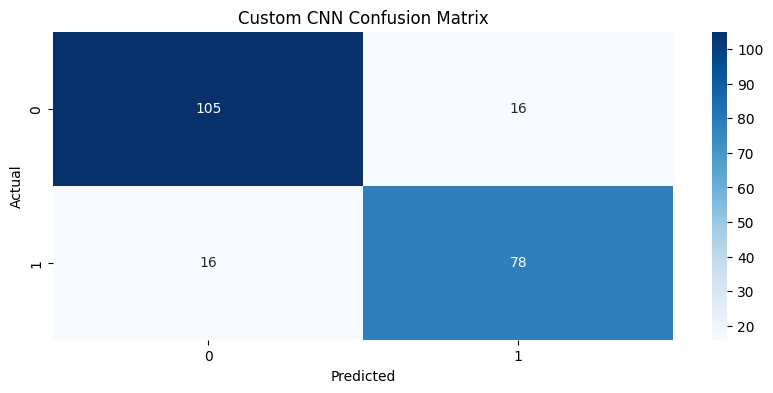

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 140ms/step - accuracy: 0.8627 - loss: 0.3626 - precision_1: 0.4187 - recall_1: 0.5035

🔍 Evaluating Transfer Learning
7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       121
           1       0.98      0.98      0.98        94

    accuracy                           0.98       215
   macro avg       0.98      0.98      0.98       215
weighted avg       0.98      0.98      0.98       215



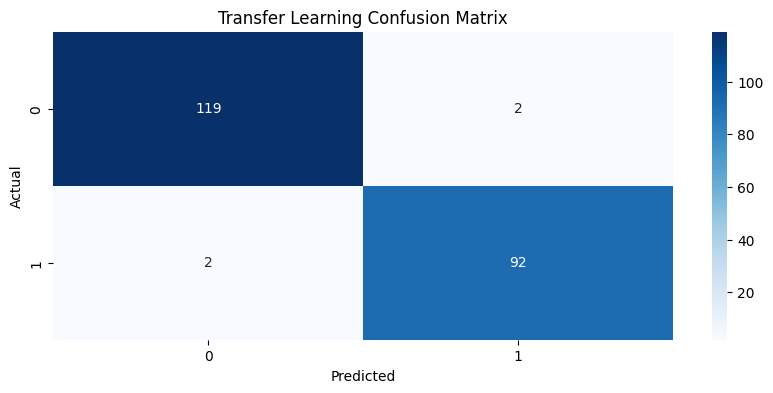

7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 411ms/step - accuracy: 0.9834 - loss: 0.0390 - precision_2: 0.5824 - recall_2: 0.6197


In [30]:
custom_acc = evaluate_model(custom_model, "Custom CNN")
transfer_acc = evaluate_model(transfer_model, "Transfer Learning")

# Plot Training Curves

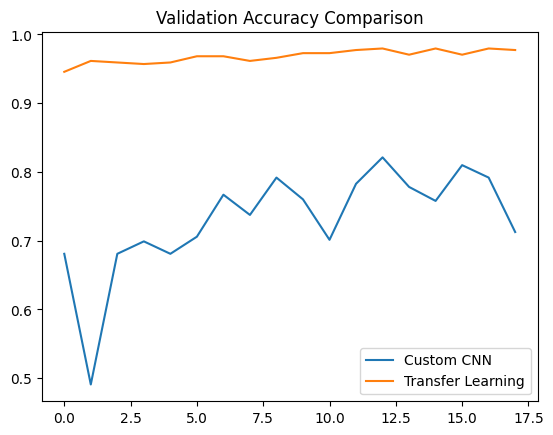

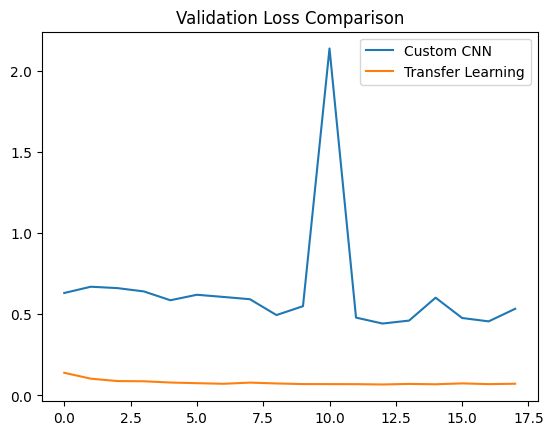

In [31]:
# Accuracy Comparison
plt.plot(history_custom.history['val_accuracy'], label="Custom CNN")
plt.plot(history_transfer.history['val_accuracy'], label="Transfer Learning")
plt.title("Validation Accuracy Comparison")
plt.legend()
plt.show()

# Loss Comparison
plt.plot(history_custom.history['val_loss'], label="Custom CNN")
plt.plot(history_transfer.history['val_loss'], label="Transfer Learning")
plt.title("Validation Loss Comparison")
plt.legend()
plt.show()

# Comparison Table

In [32]:
print("\n========== MODEL COMPARISON ==========")
print(f"Custom CNN Accuracy: {custom_acc:.4f}")
print(f"Transfer Learning Accuracy: {transfer_acc:.4f}")

print(f"\nCustom CNN Training Time: {custom_time:.2f} seconds")
print(f"Transfer Learning Training Time: {transfer_time:.2f} seconds")

if transfer_acc > custom_acc:
    print("\n🏆 Best Model: Transfer Learning")
    transfer_model.save("best_model.h5")
else:
    print("\n🏆 Best Model: Custom CNN")
    custom_model.save("best_model.h5")


========== MODEL COMPARISON ==========
Custom CNN Accuracy: 0.8512
Transfer Learning Accuracy: 0.9814

Custom CNN Training Time: 754.94 seconds
Transfer Learning Training Time: 732.22 seconds

🏆 Best Model: Transfer Learning


# Optional: YOLOv8 Object Detection

In [33]:
# installing ultralytics
!pip install ultralytics

In [34]:
# verify folder
!ls

best_model.h5		    models
classification_dataset	    object_detection_Dataset.zip
classification_dataset.zip  sample_data


In [35]:
# unzip dataset
!unzip object_detection_Dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: object_detection_Dataset/train/images/pic_414_jpg.rf.9e4f36384d82051072efe9f4ce9637d6.jpg  
  inflating: object_detection_Dataset/train/images/pic_299_jpg.rf.2b0bdf5aeb2b811a38fe505476ebc3f3.jpg  
  inflating: object_detection_Dataset/train/images/pic_269_jpg.rf.925a9678eb935a795238f33562ad4bcd.jpg  
  inflating: object_detection_Dataset/train/images/pic_219_jpg.rf.76feffe3c9fc2ea2377fdbeca41d5871.jpg  
  inflating: object_detection_Dataset/train/images/pic_287_jpg.rf.196fe25827d9b54f82c4a75dca213208.jpg  
  inflating: object_detection_Dataset/train/images/pic_300_jpg.rf.1af68bfd2fe73b082f05b9a57310130c.jpg  
  inflating: object_detection_Dataset/train/images/pic_229_jpg.rf.638669cc537ee3e25686c7fffdee1a95.jpg  
  inflating: object_detection_Dataset/train/images/pic_227_jpg.rf.ac7b57750be607ab956d469f473fa3f5.jpg  
  inflating: object_detection_Dataset/train/images/pic_229_jpg.rf.6ade69d81ba7c53e16dfe5bd14f328f9.jpg  
  in

In [36]:
# verify folder structure
!ls

best_model.h5		    models			  sample_data
classification_dataset	    object_detection_Dataset
classification_dataset.zip  object_detection_Dataset.zip


In [37]:
!ls object_detection_Dataset

data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


In [38]:
!ls object_detection_Dataset/train

images	labels


In [39]:
%%writefile data.yaml
path: /content/object_detection_Dataset

train: train
val: valid
test: test

nc: 2
names: ['bird', 'drone']

Writing data.yaml


In [40]:
# Install & Train
from ultralytics import YOLO

model = YOLO("yolov8n.pt")
model.train(
    data="/content/object_detection_Dataset/data.yaml",
    epochs=50,
    imgsz=640
)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/object_detection_Dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f5226c536e0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [41]:
!pwd

/content


In [42]:
!ls

best_model.h5		    models			  sample_data
classification_dataset	    object_detection_Dataset	  yolo26n.pt
classification_dataset.zip  object_detection_Dataset.zip  yolov8n.pt
data.yaml		    runs


In [43]:
# Validate the Model
model = YOLO("runs/detect/train/weights/best.pt")

metrics = model.val(data="/content/object_detection_Dataset/data.yaml")

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 591.2±252.8 MB/s, size: 24.2 KB)
val: Scanning /content/object_detection_Dataset/valid/labels.cache... 448 images, 6 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 448/448 144.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 5.2it/s 5.3s
                   all        448        663      0.857      0.764       0.82      0.529
                  Bird        217        414      0.797      0.645      0.714      0.418
                 drone        225        249      0.917      0.884      0.926      0.639
Speed: 2.0ms preprocess, 4.1ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to /content/runs/detect/val


In [44]:
# inference
model.predict(source="object_detection_Dataset/test/images", save=True)


image 1/224 /content/object_detection_Dataset/test/images/00083b384685315d_jpg.rf.abfd1b2cc8c681777bae66d5327bb9ea.jpg: 640x640 1 Bird, 7.2ms
image 2/224 /content/object_detection_Dataset/test/images/00188d7f40a84793_jpg.rf.7f9da2b662dc236fbdcc1f22d8e0983e.jpg: 640x640 1 Bird, 7.2ms
image 3/224 /content/object_detection_Dataset/test/images/0028adf0e92c3da2_jpg.rf.48c97d30547a46e83abcbd1bf801c72f.jpg: 640x640 1 Bird, 7.2ms
image 4/224 /content/object_detection_Dataset/test/images/00347cbbeed4bedb_jpg.rf.aa19c9a7a22d76f8539ca12ac7cb82d5.jpg: 640x640 1 Bird, 7.2ms
image 5/224 /content/object_detection_Dataset/test/images/004cc8de466969bc_jpg.rf.ca1ffa31f30a92a3987e689583983973.jpg: 640x640 1 Bird, 7.2ms
image 6/224 /content/object_detection_Dataset/test/images/006ce62a72df4dd4_jpg.rf.8f8e7b6e9a26a01be91ea1b7dc4011d2.jpg: 640x640 1 Bird, 7.2ms
image 7/224 /content/object_detection_Dataset/test/images/006f6769070fc876_jpg.rf.bda2b07a999cd589936497151e0d009f.jpg: 640x640 3 Birds, 7.2ms
imag

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'Bird', 1: 'drone'}
 obb: None
 orig_img: array([[[63, 40, 25],
         [63, 40, 25],
         [63, 40, 25],
         ...,
         [69, 44, 28],
         [69, 44, 28],
         [69, 44, 28]],
 
        [[63, 40, 25],
         [63, 40, 25],
         [63, 40, 25],
         ...,
         [69, 44, 28],
         [69, 44, 28],
         [69, 44, 28]],
 
        [[63, 40, 25],
         [63, 40, 25],
         [63, 40, 25],
         ...,
         [69, 44, 28],
         [69, 44, 28],
         [69, 44, 28]],
 
        ...,
 
        [[74, 48, 34],
         [74, 48, 34],
         [74, 48, 34],
         ...,
         [81, 55, 38],
         [81, 55, 38],
         [81, 55, 38]],
 
        [[74, 48, 34],
         [74, 48, 34],
         [74, 48, 34],
         ...,
         [81, 55, 38],
         [81, 55, 38],
         [81, 55, 38]],
 
        [[74, 48,

(np.float64(-0.5), np.float64(415.5), np.float64(415.5), np.float64(-0.5))

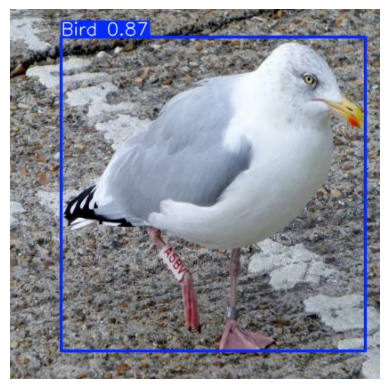

In [45]:
# display prediction
from PIL import Image
import matplotlib.pyplot as plt

# img = Image.open("runs/detect/predict/image1.jpg")
img = Image.open("/content/runs/detect/predict/00188d7f40a84793_jpg.rf.7f9da2b662dc236fbdcc1f22d8e0983e.jpg")
plt.imshow(img)
plt.axis("off")

# Streamlit Deployment

In [50]:
!pip install -q streamlit
!wget https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared-linux-amd64
import subprocess
subprocess.Popen(["./cloudflared-linux-amd64", "tunnel", "--url", "http://localhost:8501"])
!nohup /content/cloudflared-linux-amd64 tunnel --url http://localhost:8501 &

--2026-03-06 16:37:10--  https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/cloudflare/cloudflared/releases/download/2026.2.0/cloudflared-linux-amd64 [following]
--2026-03-06 16:37:11--  https://github.com/cloudflare/cloudflared/releases/download/2026.2.0/cloudflared-linux-amd64
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/106867604/f9298ca8-89c8-41fe-a51f-e24cb2059878?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-03-06T17%3A27%3A16Z&rscd=attachment%3B+filename%3Dcloudflared-linux-amd64&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-03-

In [2]:
!pip install tensorflow

In [3]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 70.9 MB/s eta 0:00:00


In [55]:
%%writefile app.py
import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image
from ultralytics import YOLO

# Page Config
st.set_page_config(page_title="Aerial Bird vs Drone Detection", layout="centered")

st.title("🐦 Bird vs 🚁 Drone Detection System")
st.write("AI system for Wildlife Protection & Airport Surveillance")
st.sidebar.title("Settings")

# Load Model (Cached)
@st.cache_resource
def load_model():
    model = tf.keras.models.load_model("best_model.h5")
    return model

@st.cache_resource
def load_yolo_model():
    return YOLO('/content/runs/detect/train/weights/best.pt')

# Image Preprocessing
IMG_SIZE = (224, 224)

def preprocess_image(image):
    image = image.resize(IMG_SIZE)
    img_array = np.array(image) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img_array

# --- Sidebar Controls ---
task = st.sidebar.radio("Select Task", ["Classification (Keras)", "Object Detection (YOLOv8)"])
conf_threshold = st.sidebar.slider("Confidence Threshold", 0.0, 1.0, 0.5)

# Upload Image
uploaded_file = st.file_uploader("Upload Image", type=["jpg", "png", "jpeg"])

if uploaded_file is not None:
    image = Image.open(uploaded_file).convert("RGB")
    col1, col2 = st.columns(2)

    with col1:
        st.subheader("Original Image")
        st.image(image, caption="Uploaded Image", use_container_width=True)
    with col2:
        st.subheader("AI Prediction")

        # -------- Classification --------
        if task == "Classification (Keras)":
          model = load_model()
          if model is not None:
            img_array = preprocess_image(image)
            prediction = model.predict(img_array)
            probability = float(prediction[0][0])

            if prediction > 0.5:
              st.error("🚁 Drone Detected!")
            else:
              st.success("🐦 Bird Detected!")

            class_idx = 1 if probability > 0.5 else 0
            label = "Drone" if class_idx == 1 else "Bird"
            confidence = probability if class_idx == 1 else (1 - probability)
            st.metric(label=f"Classified as: {label}", value=f"{confidence*100:.2f}% Confidence")

      # -------- Object Detection --------
        elif task == "Object Detection (YOLOv8)":
            model = load_yolo_model()
            img_np = np.array(image)
            results = model.predict(img_np, conf=conf_threshold)

            res_plotted = results[0].plot()
            st.image(res_plotted, caption="Detected Objects", use_container_width=True)

            if results[0].boxes is not None:
              count = len(results[0].boxes)
              st.write(f"** 🔍 Detected Objects Count:** {count}")

            for box in results[0].boxes:
                c_name = model.names[int(box.cls.item())]
                probability = float(box.conf.item())
                st.write(f"Detected **{c_name}** with {probability:.2%} probability")

else:
    st.info("Please upload an aerial image to begin.")

Overwriting app.py


In [53]:
!streamlit run /content/app.py &>/content/logs.txt &

In [54]:
!grep -o 'https://.*\.trycloudflare.com' nohup.out | head -n 1 | xargs -I {} echo "Your tunnel url {}"

Your tunnel url https://pencil-planets-betty-den.trycloudflare.com
